In [9]:
import pandas as pd

redwine = pd.read_csv("winequality-red.csv", sep=";")
X, y = redwine.iloc[:, :-1], redwine.iloc[:, -1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(100, activation='sigmoid'))
# model.add(Dropout(0.2))
# model.add(Dense(200, activation='relu'))

model.add(Dense(200, activation='relu'))
# model.add(Dropout(0.4))
# model.add(Dense(200, activation='relu'))

model.add(Dense(50, activation='tanh'))
#model.add(Dropout(0.1))
# model.add(Dense(200, activation='relu'))

model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,960 (124.84 KB)

 Trainable params: 31,960 (124.84 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard

checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True)
tensorboard = TensorBoard(log_dir="./logs-activation", histogram_freq=1, embeddings_freq=1)

In [13]:
# history = model.fit(X_train, y_train,
#                    batch_size=200, epochs=300)
history = model.fit(X_train, y_train,
                    batch_size=200, epochs=300, callbacks=[checkpoint, tensorboard],
                    validation_data=(X_test, y_test))

Epoch 1/300


I0000 00:00:1778998580.018333 1625921 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_405960__.14


1/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.0100 - loss: 5.7831

I0000 00:00:1778998581.741213 1625920 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_405960__.14


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 458ms/step - accuracy: 0.3303 - loss: 2.9998 - val_accuracy: 0.4675 - val_loss: 1.3266
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4762 - loss: 1.3965 - val_accuracy: 0.4700 - val_loss: 1.3294
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4762 - loss: 1.2622 - val_accuracy: 0.4850 - val_loss: 1.2490
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4846 - loss: 1.2321 - val_accuracy: 0.5000 - val_loss: 1.2657
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4962 - loss: 1.1947 - val_accuracy: 0.4925 - val_loss: 1.1956
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4896 - loss: 1.1895 - val_accuracy: 0.4975 - val_loss: 1.1796
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5196 - loss: 1.1641 - val_accuracy: 0.4900 - val_loss: 1.1890
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5046 - loss: 1.1515 - val_accuracy: 0.4950 - val_loss: 1.1702
Epo

In [14]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss, accuracy)

1.042954444885254 0.5799999833106995


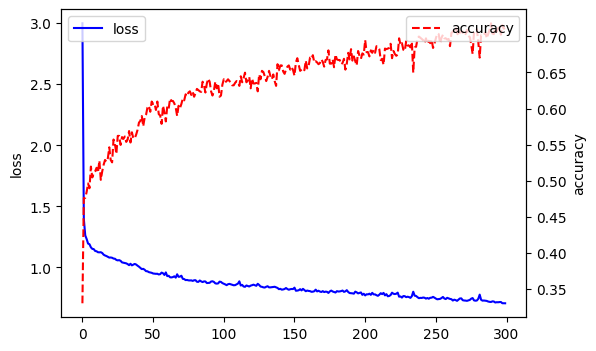

In [15]:
import matplotlib.pyplot as plt
 
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(history.history['loss'], 'b-', label='loss')
ax1.set_ylabel('loss')
ax1.legend(loc='upper left')
 
ax2 = ax1.twinx()
ax2.plot(history.history['accuracy'], 'r--', label='accuracy')
ax2.set_ylabel('accuracy')
ax2.legend(loc='upper right')
plt.show()

In [16]:
# 예측한 결과 처음 5개 출력해보기
import numpy as np
pred = model.predict(X_test)
# print(np.argmax(pred[:5], axis=1))
print(y_test[:5].values)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
[5 5 4 5 4]


- 텐서보드 실행 명령: `tensorboard --logdir=./logs`
- 브라우저에서 `http://localhost:6006`으로 확인


[Colab에서 텐서보드 실행]
- %load_exttensorboard
- %tensorboard--logdirlogs/